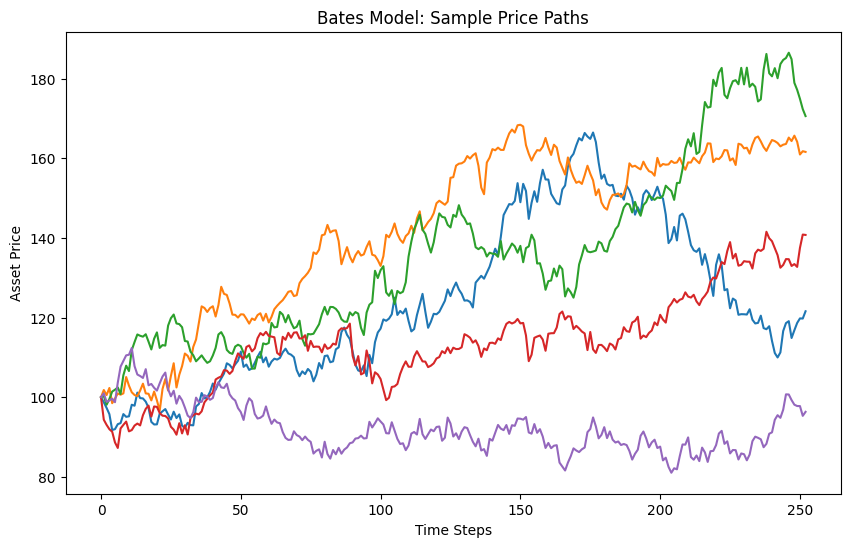

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def bates_model(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N, M):
    dt = T/N
    S = np.zeros((M, N+1))
    v = np.zeros((M, N+1))
    S[:, 0] = S0
    v[:, 0] = v0
    
    for i in range(1, N+1):
        dW1 = np.random.normal(0, np.sqrt(dt), M)
        dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), M)
        
        # Jump process
        dN = np.random.poisson(lambda_ * dt, M)
        J = np.random.normal(mu_j, sigma_j, M) * dN
        
        v[:, i] = v[:, i-1] + kappa * (theta - v[:, i-1]) * dt + sigma * np.sqrt(v[:, i-1]) * dW2
        v[:, i] = np.maximum(v[:, i], 0)  # Ensure non-negative volatility
        
        S[:, i] = S[:, i-1] * np.exp((r - 0.5*v[:, i-1] - lambda_*(np.exp(mu_j + 0.5*sigma_j**2) - 1))*dt + 
                                     np.sqrt(v[:, i-1])*dW1 + J)
    
    return S, v

# Example usage
S0, v0, r = 100, 0.1, 0.05
kappa, theta, sigma = 2, 0.1, 0.3
rho, lambda_, mu_j, sigma_j = -0.5, 0.1, -0.05, 0.1
T, N, M = 1, 252, 1000

S, v = bates_model(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N, M)

plt.figure(figsize=(10, 6))
plt.plot(S[:5].T)
plt.title('Bates Model: Sample Price Paths')
plt.xlabel('Time Steps')
plt.ylabel('Asset Price')
plt.show()

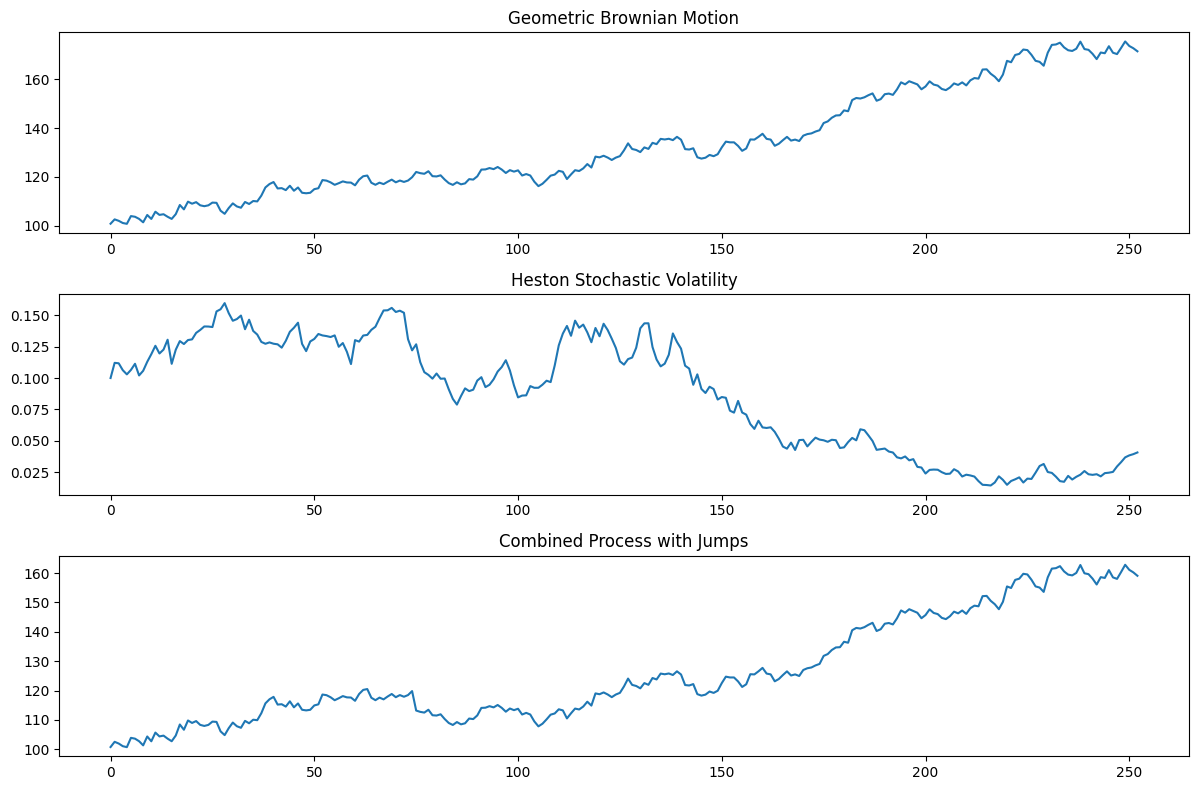

In [2]:
import numpy as np

def geometric_brownian_motion(S0, mu, sigma, T, N):
    dt = T/N
    t = np.linspace(0, T, N+1)
    W = np.random.standard_normal(size=N+1)
    W = np.cumsum(W)*np.sqrt(dt)
    S = S0*np.exp((mu-0.5*sigma**2)*t + sigma*W)
    return S

def heston_volatility(v0, kappa, theta, sigma, T, N):
    dt = T/N
    v = np.zeros(N+1)
    v[0] = v0
    for i in range(1, N+1):
        dW = np.random.normal(0, np.sqrt(dt))
        v[i] = v[i-1] + kappa*(theta - v[i-1])*dt + sigma*np.sqrt(v[i-1])*dW
        v[i] = max(v[i], 0)  # Ensure non-negative volatility
    return v

def jump_process(lambda_, mu_j, sigma_j, T, N):
    dt = T/N
    dN = np.random.poisson(lambda_ * dt, N+1)
    J = np.random.normal(mu_j, sigma_j, N+1) * dN
    return np.cumsum(J)

# Example usage
S0, mu, sigma = 100, 0.05, 0.2
v0, kappa, theta, sigma_v = 0.1, 2, 0.1, 0.3
lambda_, mu_j, sigma_j = 0.1, -0.05, 0.1
T, N = 1, 252

gbm = geometric_brownian_motion(S0, mu, sigma, T, N)
heston_vol = heston_volatility(v0, kappa, theta, sigma_v, T, N)
jumps = jump_process(lambda_, mu_j, sigma_j, T, N)

# Combine components (simplified, not full Bates model)
S_combined = gbm * np.exp(jumps)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(gbm)
plt.title('Geometric Brownian Motion')
plt.subplot(3, 1, 2)
plt.plot(heston_vol)
plt.title('Heston Stochastic Volatility')
plt.subplot(3, 1, 3)
plt.plot(S_combined)
plt.title('Combined Process with Jumps')
plt.tight_layout()
plt.show()

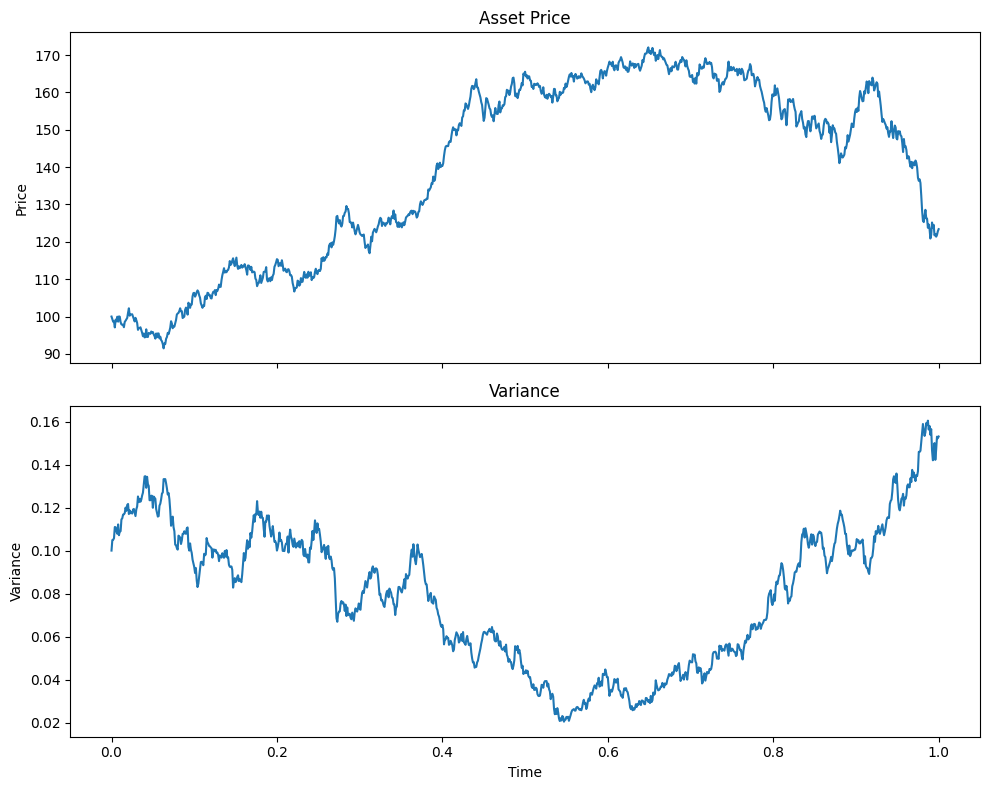

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def bates_sde(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N):
    dt = T/N
    t = np.linspace(0, T, N+1)
    S = np.zeros(N+1)
    v = np.zeros(N+1)
    S[0] = S0
    v[0] = v0
    
    for i in range(1, N+1):
        dW1 = np.random.normal(0, np.sqrt(dt))
        dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt))
        
        # Jump process
        dN = np.random.poisson(lambda_ * dt)
        J = np.random.normal(mu_j, sigma_j) if dN > 0 else 0
        
        k = np.exp(mu_j + 0.5*sigma_j**2) - 1
        
        v[i] = v[i-1] + kappa * (theta - v[i-1]) * dt + sigma * np.sqrt(v[i-1]) * dW2
        v[i] = max(v[i], 0)  # Ensure non-negative volatility
        
        S[i] = S[i-1] * np.exp((r - lambda_*k - 0.5*v[i-1])*dt + np.sqrt(v[i-1])*dW1 + J*dN)
    
    return t, S, v

# Example usage
S0, v0, r = 100, 0.1, 0.05
kappa, theta, sigma = 2, 0.1, 0.3
rho, lambda_, mu_j, sigma_j = -0.5, 0.1, -0.05, 0.1
T, N = 1, 1000

t, S, v = bates_sde(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(t, S)
ax1.set_title('Asset Price')
ax1.set_ylabel('Price')
ax2.plot(t, v)
ax2.set_title('Variance')
ax2.set_xlabel('Time')
ax2.set_ylabel('Variance')
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from scipy.optimize import minimize

def log_likelihood(params, S, dt):
    S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j = params
    
    N = len(S) - 1
    log_returns = np.log(S[1:] / S[:-1])
    
    # Simplification: Assume constant volatility for this example
    v = v0 * np.ones(N)
    
    # Jump component
    jump_mean = lambda_ * dt * (np.exp(mu_j + 0.5*sigma_j**2) - 1)
    jump_var = lambda_ * dt * (np.exp(2*mu_j + sigma_j**2) * (np.exp(sigma_j**2) - 1) + (np.exp(mu_j + 0.5*sigma_j**2) - 1)**2)
    
    # Total mean and variance
    total_mean = (r - 0.5*v - jump_mean) * dt
    total_var = v*dt + jump_var
    
    # Log-likelihood
    ll = -0.5 * np.sum(np.log(2*np.pi*total_var) + (log_returns - total_mean)**2 / total_var)
    
    return -ll  # Minimize negative log-likelihood

# Example usage
np.random.seed(42)
S0, v0, r = 100, 0.1, 0.05
kappa, theta, sigma = 2, 0.1, 0.3
rho, lambda_, mu_j, sigma_j = -0.5, 0.1, -0.05, 0.1
T, N = 1, 252
dt = T/N

# Generate sample data
t, S, _ = bates_sde(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N)

# Initial guess for parameters
initial_params = [S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j]

# Optimize
result = minimize(log_likelihood, initial_params, args=(S, dt), method='Nelder-Mead')

print("Estimated parameters:")
print(result.x)
print("\nTrue parameters:")
print(initial_params)

Estimated parameters:
[ 1.13715479e+01  2.04901152e-01 -8.71094393e-02  4.05439029e+00
 -6.42377067e-03  4.17631346e-01 -1.10142039e+00  1.65224589e-01
 -1.24012278e-01 -3.83981876e-02]

True parameters:
[100, 0.1, 0.05, 2, 0.1, 0.3, -0.5, 0.1, -0.05, 0.1]


In [6]:
import numpy as np
from scipy.stats import norm

def bates_option_price(S0, K, T, r, v0, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, option_type='call', M=10000, N=252):
    dt = T/N
    
    # Generate paths
    S, _ = bates_model(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N, M)
    
    # Calculate payoffs
    if option_type.lower() == 'call':
        payoffs = np.maximum(S[:, -1] - K, 0)
    elif option_type.lower() == 'put':
        payoffs = np.maximum(K - S[:, -1], 0)
    else:
        raise ValueError("Option type must be 'call' or 'put'")
    
    # Discount payoffs
    option_price = np.exp(-r*T) * np.mean(payoffs)
    
    return option_price

# Example usage
S0, K, T, r = 100, 100, 1, 0.05
v0, kappa, theta, sigma = 0.1, 2, 0.1, 0.3
rho, lambda_, mu_j, sigma_j = -0.5, 0.1, -0.05, 0.1

call_price = bates_option_price(S0, K, T, r, v0, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, 'call')
put_price = bates_option_price(S0, K, T, r, v0, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, 'put')

print(f"Call option price: {call_price:.4f}")
print(f"Put option price: {put_price:.4f}")

# Comparison with Black-Scholes
def black_scholes(S0, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    if option_type.lower() == 'call':
        price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    elif option_type.lower() == 'put':
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)
    else:
        raise ValueError("Option type must be 'call' or 'put'")
    
    return price

bs_call = black_scholes(S0, K, T, r, np.sqrt(v0), 'call')
bs_put = black_scholes(S0, K, T, r, np.sqrt(v0), 'put')

print(f"Black-Scholes call price: {bs_call:.4f}")
print(f"Black-Scholes put price: {bs_put:.4f}")

Call option price: 14.8304
Put option price: 9.9782
Black-Scholes call price: 14.8470
Black-Scholes put price: 9.9700


In [7]:
import numpy as np
from scipy.optimize import minimize

def bates_option_price(params, S0, K, T, r, option_type):
    v0, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j = params
    price = monte_carlo_bates(S0, K, T, r, v0, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, option_type)
    return price

def objective_function(params, market_prices, S0, K, T, r, option_types):
    model_prices = [bates_option_price(params, S0, K[i], T[i], r, option_types[i]) for i in range(len(market_prices))]
    return np.sum((np.array(model_prices) - np.array(market_prices))**2)

# Example market data (simplified)
market_prices = [2.5, 3.0, 2.8, 3.2]
S0, K, T, r = 100, [98, 100, 102, 104], [0.5, 0.5, 1, 1], 0.05
option_types = ['call', 'call', 'put', 'put']

# Initial guess for parameters
initial_params = [0.1, 2, 0.1, 0.3, -0.5, 0.1, -0.05, 0.1]

# Optimize
result = minimize(objective_function, initial_params, args=(market_prices, S0, K, T, r, option_types), method='Nelder-Mead')

print("Calibrated parameters:")
print(result.x)

NameError: name 'monte_carlo_bates' is not defined

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_sensitivities(base_params, param_ranges, S0, K, T, r):
    v0, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j = base_params
    results = {}

    for param, range_values in param_ranges.items():
        prices = []
        for value in range_values:
            params = base_params
            params[param] = value
            price = bates_option_price(S0, K, T, r, *params)
            prices.append(price)
        results[param] = (range_values, prices)

    return results

# Base parameters and ranges to test
base_params = [0.1, 2, 0.1, 0.3, -0.5, 0.1, -0.05, 0.1]
param_ranges = {
    1: np.linspace(1, 3, 20),  # kappa
    2: np.linspace(0.05, 0.15, 20),  # theta
    5: np.linspace(0.05, 0.15, 20),  # lambda
}

S0, K, T, r = 100, 100, 1, 0.05

results = calculate_sensitivities(base_params, param_ranges, S0, K, T, r)

# Plot results
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
param_names = ['kappa', 'theta', 'lambda']

for i, (param, (range_values, prices)) in enumerate(results.items()):
    axs[i].plot(range_values, prices)
    axs[i].set_xlabel(param_names[i])
    axs[i].set_ylabel('Option Price')
    axs[i].set_title(f'Sensitivity to {param_names[i]}')

plt.tight_layout()
plt.show()

TypeError: bates_option_price() takes 6 positional arguments but 12 were given

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def compare_models(S0, K, T, r, sigma, v0, kappa, theta, sigma_v, rho, lambda_, mu_j, sigma_j):
    # Black-Scholes
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    bs_price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    # Heston (simplified Monte Carlo)
    heston_price = heston_monte_carlo(S0, K, T, r, v0, kappa, theta, sigma_v, rho)

    # Bates
    bates_price = bates_option_price(S0, K, T, r, v0, kappa, theta, sigma_v, rho, lambda_, mu_j, sigma_j)

    return bs_price, heston_price, bates_price

# Example usage
S0, K, T, r = 100, 100, 1, 0.05
sigma = 0.2
v0, kappa, theta, sigma_v = 0.1, 2, 0.1, 0.3
rho, lambda_, mu_j, sigma_j = -0.5, 0.1, -0.05, 0.1

bs, heston, bates = compare_models(S0, K, T, r, sigma, v0, kappa, theta, sigma_v, rho, lambda_, mu_j, sigma_j)

print(f"Black-Scholes price: {bs:.4f}")
print(f"Heston price: {heston:.4f}")
print(f"Bates price: {bates:.4f}")

# Plot comparison
models = ['Black-Scholes', 'Heston', 'Bates']
prices = [bs, heston, bates]

plt.figure(figsize=(10, 6))
plt.bar(models, prices)
plt.title('Option Price Comparison')
plt.ylabel('Option Price')
plt.show()

NameError: name 'heston_monte_carlo' is not defined

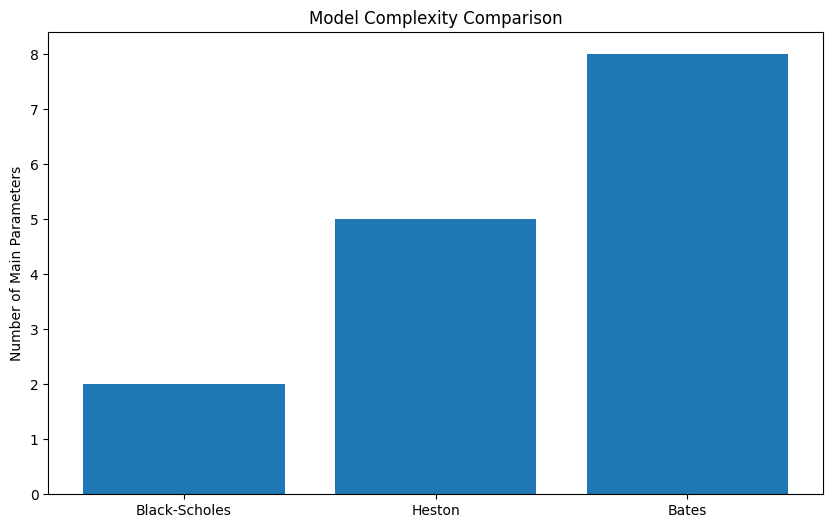

NameError: name 'time' is not defined

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def parameter_count_comparison():
    models = ['Black-Scholes', 'Heston', 'Bates']
    param_counts = [2, 5, 8]  # Simplified count of main parameters

    plt.figure(figsize=(10, 6))
    plt.bar(models, param_counts)
    plt.title('Model Complexity Comparison')
    plt.ylabel('Number of Main Parameters')
    plt.show()

def computation_time_comparison(N):
    times = []
    for _ in range(N):
        start = time.time()
        # Black-Scholes
        bs_price = black_scholes(S0, K, T, r, sigma)
        bs_time = time.time() - start

        start = time.time()
        # Heston (simplified)
        heston_price = heston_monte_carlo(S0, K, T, r, v0, kappa, theta, sigma_v, rho)
        heston_time = time.time() - start

        start = time.time()
        # Bates
        bates_price = bates_option_price(S0, K, T, r, v0, kappa, theta, sigma_v, rho, lambda_, mu_j, sigma_j)
        bates_time = time.time() - start

        times.append([bs_time, heston_time, bates_time])

    avg_times = np.mean(times, axis=0)
    
    plt.figure(figsize=(10, 6))
    plt.bar(models, avg_times)
    plt.title('Average Computation Time Comparison')
    plt.ylabel('Time (seconds)')
    plt.show()

parameter_count_comparison()
computation_time_comparison(100)  # Run 100 times and take average

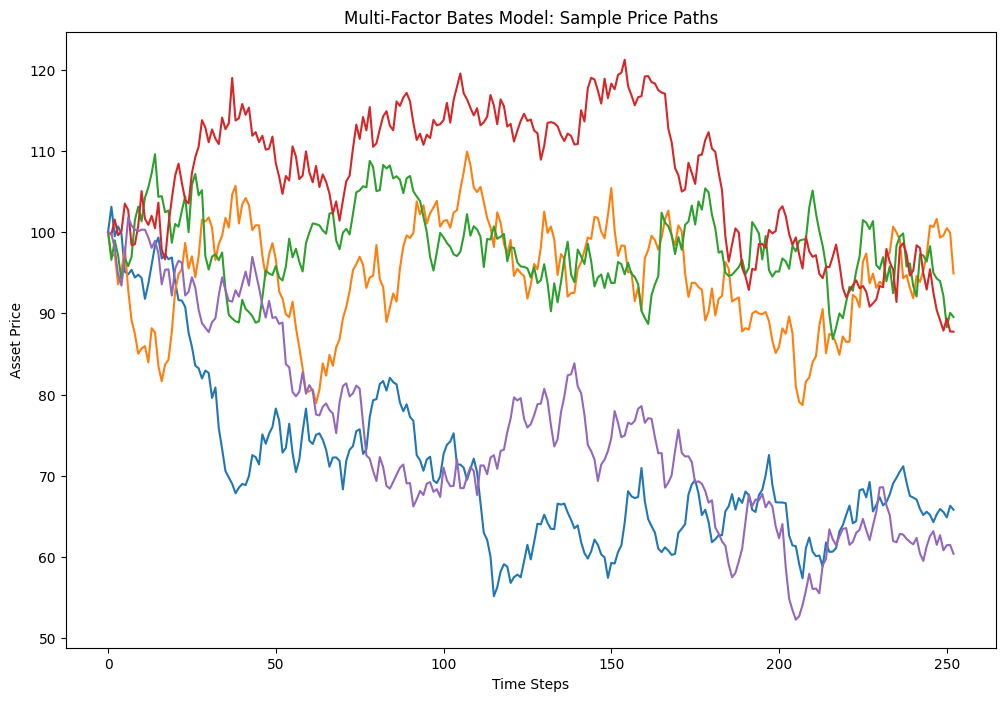

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def multi_factor_bates(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N, M, num_factors=2):
    dt = T/N
    S = np.zeros((M, N+1))
    v = np.zeros((M, N+1, num_factors))
    S[:, 0] = S0
    v[:, 0, :] = v0
    
    for i in range(1, N+1):
        dW = np.random.normal(0, np.sqrt(dt), (M, num_factors+1))
        
        # Correlated Brownian motions
        for j in range(1, num_factors+1):
            dW[:, j] = rho[j-1] * dW[:, 0] + np.sqrt(1 - rho[j-1]**2) * dW[:, j]
        
        # Update volatilities
        for j in range(num_factors):
            v[:, i, j] = v[:, i-1, j] + kappa[j] * (theta[j] - v[:, i-1, j]) * dt + sigma[j] * np.sqrt(v[:, i-1, j]) * dW[:, j+1]
            v[:, i, j] = np.maximum(v[:, i, j], 0)
        
        # Jump process
        dN = np.random.poisson(lambda_ * dt, M)
        J = np.random.normal(mu_j, sigma_j, M) * dN
        
        # Update asset price
        total_var = np.sum(v[:, i], axis=1)
        S[:, i] = S[:, i-1] * np.exp((r - 0.5*total_var - lambda_*(np.exp(mu_j + 0.5*sigma_j**2) - 1))*dt + 
                                     np.sqrt(total_var)*dW[:, 0] + J)
    
    return S, v

# Example usage
S0, r = 100, 0.05
v0 = [0.1, 0.05]
kappa = [2, 1]
theta = [0.1, 0.05]
sigma = [0.3, 0.2]
rho = [-0.5, -0.3]
lambda_, mu_j, sigma_j = 0.1, -0.05, 0.1
T, N, M = 1, 252, 1000

S, v = multi_factor_bates(S0, v0, r, kappa, theta, sigma, rho, lambda_, mu_j, sigma_j, T, N, M)

plt.figure(figsize=(12, 8))
plt.plot(S[:5].T)
plt.title('Multi-Factor Bates Model: Sample Price Paths')
plt.xlabel('Time Steps')
plt.ylabel('Asset Price')
plt.show()